In [ ]:
! pip install xgboost

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
import numpy as np

In [ ]:
# Load and Split Data
df = pd.read_csv('cleaned_ethereum_data.csv')
X = df.drop('FLAG', axis=1)
y = df['FLAG']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Setup Scaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

#scale_weight for XGboost
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
estimated_contamination = num_pos / len(y_train)
xgb_scale_weight = num_neg / num_pos

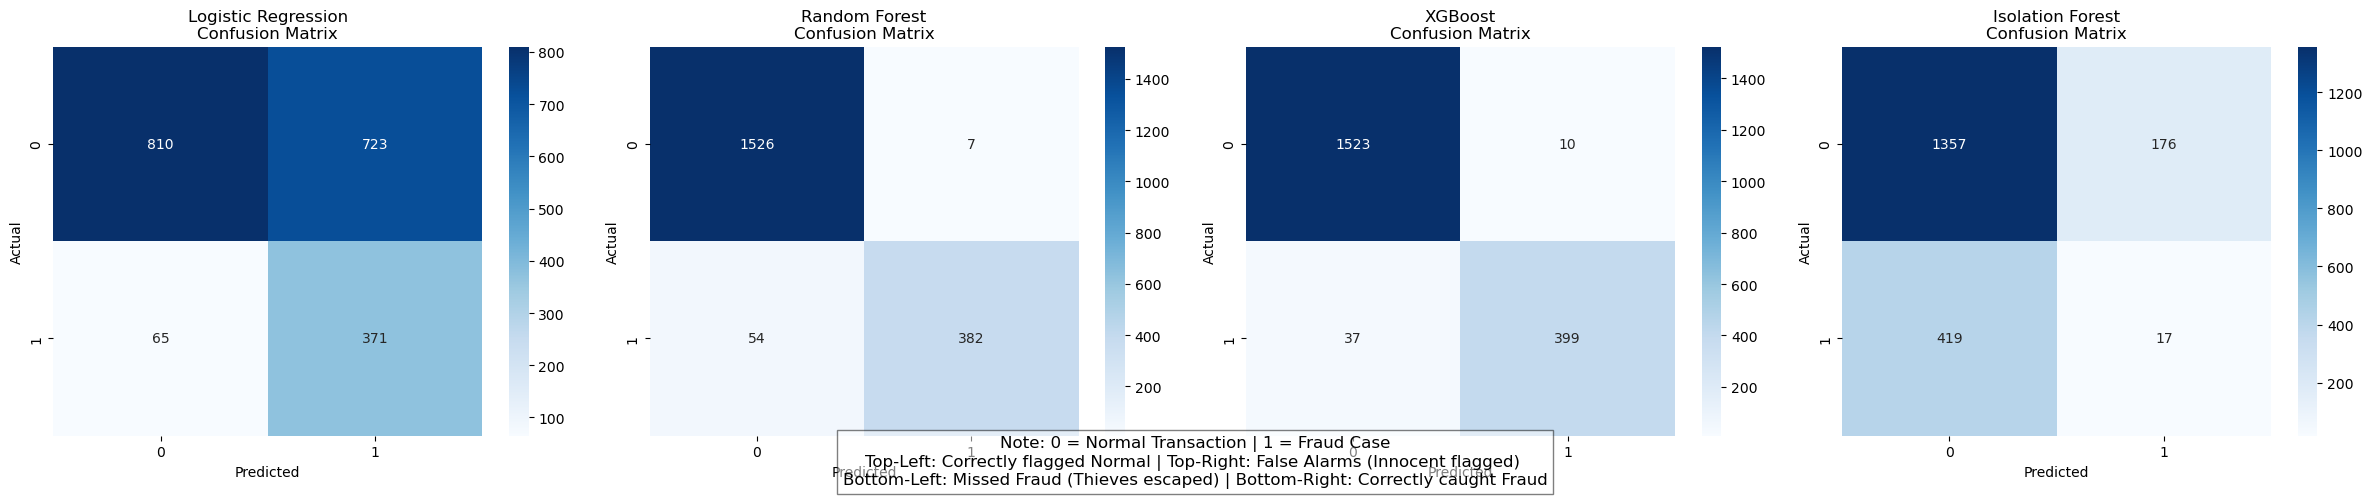

In [ ]:
# Define and Train Initial 4 Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss',scale_pos_weight=xgb_scale_weight, random_state=42),
    "Isolation Forest": IsolationForest(contamination=0.1, random_state=42)
}

model_performance = []
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, (name, model) in enumerate(models.items()):
    if name == "Isolation Forest":
        model.fit(X_train)
        y_pred = [1 if p == -1 else 0 for p in model.predict(X_test)]
        if_scores = model.decision_function(X_test_scaled)
    elif name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

 # Performance Mapping
    report = classification_report(y_test, y_pred, output_dict=True)
    model_performance.append({
        "Model": name,
        "F1-Score": report['1']['f1-score'],
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "Accuracy": round(report['accuracy'], 4)
    })
    # Confusion Matrix Rendering
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{name}\nConfusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Adding dynamic presentation context notes at the baseline
fig.text(0.5, 0.02,
         "Note: 0 = Normal Transaction | 1 = Fraud Case\n"
         "Top-Left: Correctly flagged Normal | Top-Right: False Alarms (Innocent flagged) \n"
         "Bottom-Left: Missed Fraud (Thieves escaped) | Bottom-Right: Correctly caught Fraud",
         ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))

plt.subplots_adjust(bottom=0.2)
plt.tight_layout()
plt.show()

In [ ]:
#BASIC_4models performance
print("\n----4-models performance comparison----")
print(pd.DataFrame(model_performance))


----4-models performance comparison----
                 Model  F1-Score  Precision    Recall  Accuracy
0  Logistic Regression  0.484967   0.339122  0.850917    0.5998
1        Random Forest  0.926061   0.982005  0.876147    0.9690
2              XGBoost  0.944379   0.975550  0.915138    0.9761
3     Isolation Forest  0.054054   0.088083  0.038991    0.6978


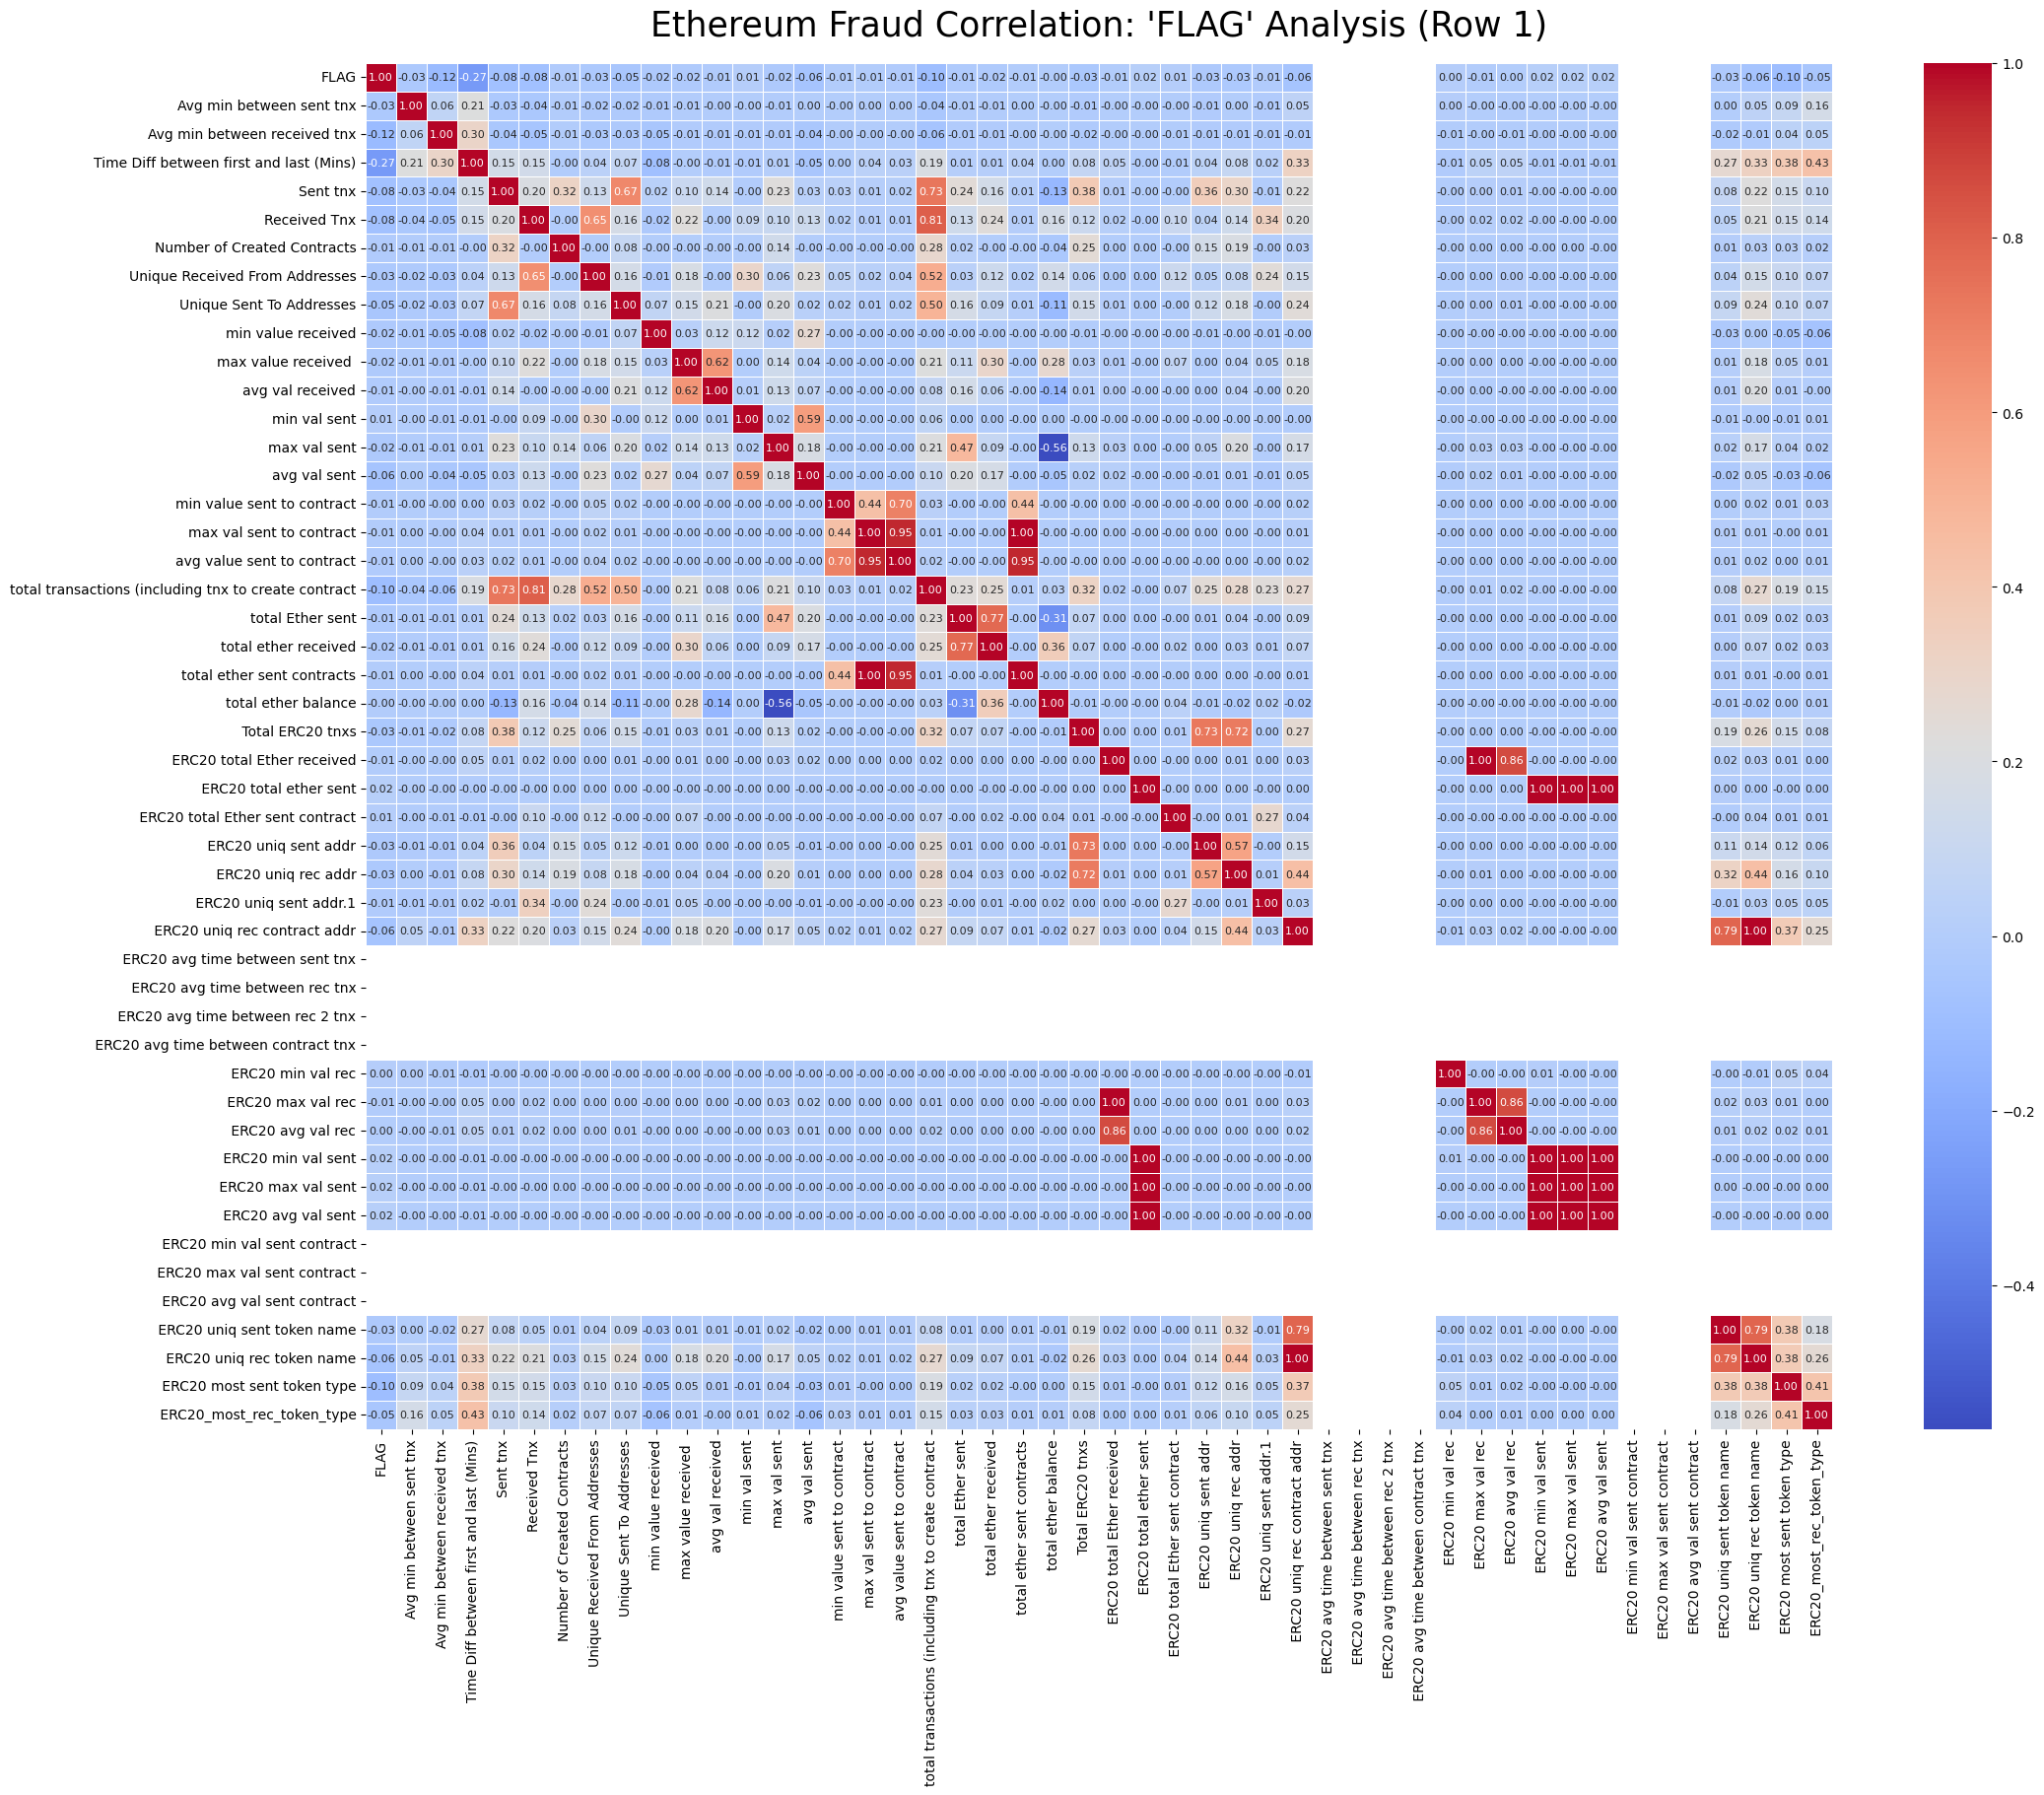


TOP 15 FEATURES FOR MODELS
FLAG                                                    1.000000
Time Diff between first and last (Mins)                 0.269354
Avg min between received tnx                            0.118533
total transactions (including tnx to create contract    0.100289
 ERC20 most sent token type                             0.099595
Received Tnx                                            0.079316
Sent tnx                                                0.078006
avg val sent                                            0.063556
 ERC20 uniq rec token name                              0.062397
 ERC20 uniq rec contract addr                           0.061948
 ERC20_most_rec_token_type                              0.049995
Unique Sent To Addresses                                0.045584
 Total ERC20 tnxs                                       0.034500
Unique Received From Addresses                          0.031941
Avg min between sent tnx                                0.0297

In [ ]:
df_clean = pd.read_csv('cleaned_ethereum_data.csv')

# Calculate the correlation matrix
corr_matrix = df_clean.corr()

# Force 'FLAG' to be the first row and first column for easy reading
cols = ['FLAG'] + [c for c in corr_matrix.columns if c != 'FLAG']
corr_matrix = corr_matrix.loc[cols, cols]

plt.figure(figsize=(24, 18))  # Large size to handle many features

sns.heatmap(corr_matrix, 
            annot=True,      
            cmap='coolwarm', 
            linewidths=0.5,
            fmt=".2f",
            annot_kws={"size": 8}
            )


plt.title("Ethereum Fraud Correlation: 'FLAG' Analysis (Row 1)", fontsize=25, pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

print("\n" + "="*40)
print("TOP 15 FEATURES FOR MODELS")
print("="*40)
top_correlations = corr_matrix['FLAG'].abs().sort_values(ascending=False)
print(top_correlations.head(16))

In [ ]:
# Heapmap Feature_selection (Top 5, Top 10, Top 15)
all_cols = X_train.columns.tolist()

def get_col(keyword):
    match = [c for c in all_cols if keyword.lower() in c.lower()]
    return match[0] if match else None

try:
    # Top 5 Highly Correlated Features
    top_5_raw = [
        get_col('Time Diff between first and last'),
        get_col('Avg min between received tnx'),
        get_col('total transactions (including tnx'),
        get_col('Received Tnx'),
        get_col('Sent tnx')
    ]

    # Top 10 Features
    top_10_raw = top_5_raw + [
        get_col('avg val sent'),
        get_col('ERC20 uniq rec token name'),
        get_col('ERC20 uniq rec contract addr'),
        get_col('Unique Sent To Addresses'),
        get_col('Total ERC20 tnxs')
    ]

    # Top 15 Features
    top_15_raw = top_10_raw + [
        get_col('Unique Received From Addresses'),
        get_col('Avg min between sent tnx'),
        get_col('ERC20 uniq rec addr'),
        get_col('ERC20 uniq sent token name'),
        get_col('ERC20 uniq sent addr')
    ]

    # FIXED: Clean and parse exact lists to clear structural bugs from prior version
    top_5 = list(dict.fromkeys([c for c in top_5_raw if c]))
    top_10 = list(dict.fromkeys([c for c in top_10_raw if c]))
    top_15 = list(dict.fromkeys([c for c in top_15_raw if c]))

except Exception as e:
    print(f"Mapping error: {e}")
    top_5, top_10, top_15 = all_cols[:5], all_cols[:10], all_cols[:15]

# Update targeted feature sets dictionary configuration
feature_sets = {
    "Top 5 Features": top_5,
    "Top 10 Features": top_10,
    "Top 15 Features": top_15,
    "All Features": all_cols
}


# Run Targeted Multi-Subset Feature Experimentations
exp_results = []
for label, cols in feature_sets.items():
    # 1. Train XGBoost Variant
    xgb_exp = XGBClassifier(eval_metric='logloss', scale_pos_weight=xgb_scale_weight,random_state=42)
    xgb_exp.fit(X_train[cols], y_train)
    y_pred_xgb = xgb_exp.predict(X_test[cols])

    # 2. Train Random Forest Variant
    rf_exp = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf_exp.fit(X_train[cols], y_train)
    y_pred_rf = rf_exp.predict(X_test[cols])

    # Metrics Logging Configuration
    exp_results.append({
        "Set": label,
        "Model": "XGBoost",
        "F1-Score": round(f1_score(y_test, y_pred_xgb), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred_xgb), 4)
    })

    exp_results.append({
        "Set": label,
        "Model": "Random Forest",
        "F1-Score": round(f1_score(y_test, y_pred_rf), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred_rf), 4)
    })

df_exp = pd.DataFrame(exp_results)


# Performance Reports Outputs
print("\n----4-models performance comparison----")
print(pd.DataFrame(model_performance))

print("\n----XGB & RF performance based on features 5,10,15,all----")
print(df_exp.to_string(index=False))



----4-models performance comparison----
                 Model  F1-Score  Precision    Recall  Accuracy
0  Logistic Regression  0.484967   0.339122  0.850917    0.5998
1        Random Forest  0.926061   0.982005  0.876147    0.9690
2              XGBoost  0.944379   0.975550  0.915138    0.9761
3     Isolation Forest  0.054054   0.088083  0.038991    0.6978

----XGB & RF performance based on features 5,10,15,all----
            Set         Model  F1-Score  Accuracy
 Top 5 Features       XGBoost    0.7952    0.9055
 Top 5 Features Random Forest    0.7862    0.9116
Top 10 Features       XGBoost    0.8558    0.9360
Top 10 Features Random Forest    0.8652    0.9441
Top 15 Features       XGBoost    0.8902    0.9512
Top 15 Features Random Forest    0.8791    0.9497
   All Features       XGBoost    0.9444    0.9761
   All Features Random Forest    0.9261    0.9690



Generating XGBoost Feature Importance Visualization...


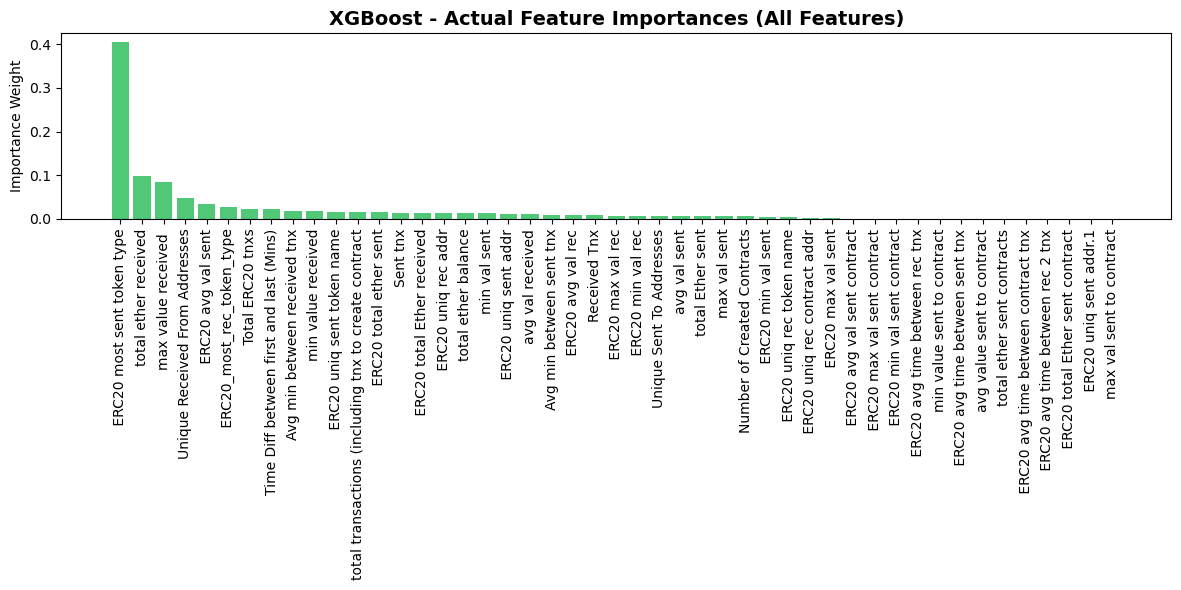


Generating Random Forest Feature Importance Visualization...


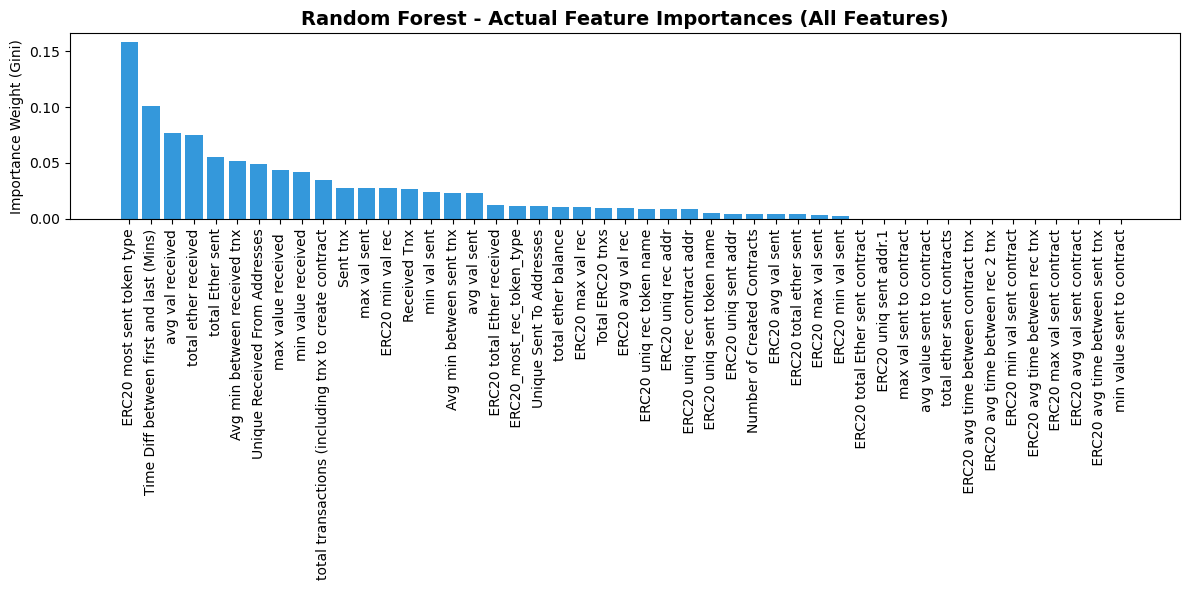


  RUNNING MULTI-SUBSET COMPARISON (TOP 5, 10, 15 vs ALL FEATURES)  

---------------------------------------------------------------------------
Model           | Feature Subset   | F1-Score   | Precision  | Recall     | Accuracy  
---------------------------------------------------------------------------
XGBoost         | All Features     | 0.9444     | 0.9756     | 0.9151     | 0.9761    
XGBoost         | Top 5 Features   | 0.8479     | 0.8275     | 0.8693     | 0.9309    
XGBoost         | Top 10 Features  | 0.9259     | 0.9346     | 0.9174     | 0.9675    
XGBoost         | Top 15 Features  | 0.9276     | 0.9452     | 0.9106     | 0.9685    
Random Forest   | All Features     | 0.9261     | 0.9820     | 0.8761     | 0.9690    
Random Forest   | Top 5 Features   | 0.8793     | 0.9495     | 0.8188     | 0.9502    
Random Forest   | Top 10 Features  | 0.9078     | 0.9639     | 0.8578     | 0.9614    
Random Forest   | Top 15 Features  | 0.9133     | 0.9765     | 0.8578     | 0.9639

In [ ]:
#Feature Importance and its performance based on Top5,10,15

#XGBOOST IMPORTANCE FEATURES
print("\nGenerating XGBoost Feature Importance Visualization...")
trained_xgb_model = models["XGBoost"]

xgb_importances = trained_xgb_model.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1]  # Sort from highest to lowest

plt.figure(figsize=(12, 6))
plt.title("XGBoost - Actual Feature Importances (All Features)", fontsize=14, fontweight='bold')
plt.bar(range(X_train.shape[1]), xgb_importances[xgb_indices], color='#50C878', align="center")
plt.xticks(range(X_train.shape[1]), [X_train.columns[idx] for idx in xgb_indices], rotation=90)
plt.ylabel("Importance Weight")
plt.tight_layout()
plt.show()

#RANDOM FOREST IMPORTANT FEATURES
print("\nGenerating Random Forest Feature Importance Visualization...")
trained_rf_model = models["Random Forest"]

rf_importances = trained_rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]  # Sort from highest to lowest

plt.figure(figsize=(12, 6))
plt.title("Random Forest - Actual Feature Importances (All Features)", fontsize=14, fontweight='bold')
plt.bar(range(X_train.shape[1]), rf_importances[rf_indices], color='#3498db', align="center")
plt.xticks(range(X_train.shape[1]), [X_train.columns[idx] for idx in rf_indices], rotation=90)
plt.ylabel("Importance Weight (Gini)")
plt.tight_layout()
plt.show()

#Feature comparison based on Top5,10,15
print("\n" + "=" * 65)
print("  RUNNING MULTI-SUBSET COMPARISON (TOP 5, 10, 15 vs ALL FEATURES)  ")
print("=" * 65)

subset_sizes = [5, 10, 15]
comparison_results = []

# Target two tree-based models
target_models = {
    "XGBoost": {
        "class": XGBClassifier(eval_metric='logloss', scale_pos_weight=xgb_scale_weight,random_state=42),
        "sorted_indices": xgb_indices
    },
    "Random Forest": {
        "class": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
        "sorted_indices": rf_indices
    }
}

# Loop through each model type
for model_name, config in target_models.items():

    # 1. Capture the 'All Features' baseline score first
    baseline_perf = next(m for m in model_performance if m['Model'] == model_name)
    comparison_results.append({
        "Model": model_name,
        "Feature Subset": "All Features",
        "Total Features": X_train.shape[1],
        "F1-Score": round(baseline_perf['F1-Score'], 4),
        "Precision": round(baseline_perf['Precision'], 4),
        "Recall": round(baseline_perf['Recall'], 4),
        "Accuracy": round(baseline_perf['Accuracy'], 4)
    })

    # Evaluate specific Top N subsets dynamically based on model's feature importance
    for n in subset_sizes:
        # Get top N features for this specific model
        top_n_indices = config["sorted_indices"][:n]
        top_n_features = [X_train.columns[idx] for idx in top_n_indices]

        # Slice data
        X_train_sub = X_train[top_n_features]
        X_test_sub = X_test[top_n_features]

        # Clone model structure, train, and predict
        sub_model = config["class"]
        sub_model.fit(X_train_sub, y_train)
        y_pred_sub = sub_model.predict(X_test_sub)

        # Calculate performance
        rep = classification_report(y_test, y_pred_sub, output_dict=True)

        comparison_results.append({
            "Model": model_name,
            "Feature Subset": f"Top {n} Features",
            "Total Features": n,
            "F1-Score": round(rep['1']['f1-score'], 4),
            "Precision": round(rep['1']['precision'], 4),
            "Recall": round(rep['1']['recall'], 4),
            "Accuracy": round(rep['accuracy'], 4)
        })

#print the performance
df_comparison = pd.DataFrame(comparison_results)

print("\n" + "-" * 75)
print(
    f"{'Model':<15} | {'Feature Subset':<16} | {'F1-Score':<10} | {'Precision':<10} | {'Recall':<10} | {'Accuracy':<10}")
print("-" * 75)

for _, row in df_comparison.iterrows():
    print(
        f"{row['Model']:<15} | {row['Feature Subset']:<16} | {row['F1-Score']:<10.4f} | {row['Precision']:<10.4f} | {row['Recall']:<10.4f} | {row['Accuracy']:<10.4f}")

print("-" * 75)

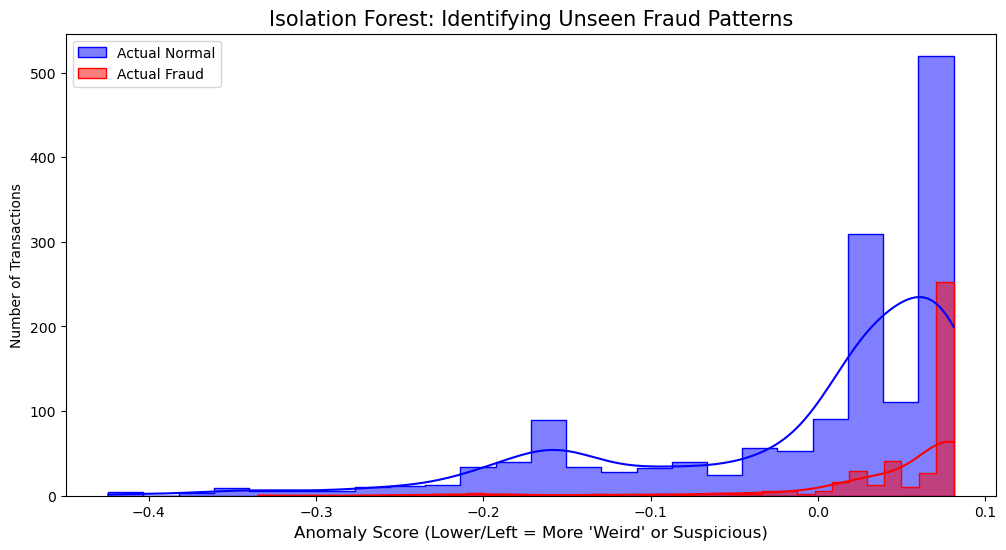

In [ ]:
# 7. Anomaly Distribution Diagnostics (Isolation Forest Visual)
plt.figure(figsize=(12, 6))
sns.histplot(if_scores[y_test == 0], color='blue', label='Actual Normal', kde=True, element="step")
sns.histplot(if_scores[y_test == 1], color='red', label='Actual Fraud', kde=True, element="step")

plt.title("Isolation Forest: Identifying Unseen Fraud Patterns", fontsize=15)
plt.xlabel("Anomaly Score (Lower/Left = More 'Weird' or Suspicious)", fontsize=12)
plt.ylabel("Number of Transactions")
plt.legend()
plt.savefig('isolation_forest_analysis.png', dpi=300)
plt.show()


In [ ]:
# EXPERIMENTAL ABLATION STUDY (dropping key features)

print("\n--- Running Experimental Ablation Study ---")

# key features to drop / testing by dropping one feature by feature
keywords_to_drop = [
    'ERC20 most sent token type',
    'total ether received',   
    'max value received',
    'Unique received from Addresses',
    'ERC20 avg val sent'    
]

# Automatically find the real column names in the actual dataset
features_to_drop = []
all_actual_columns = X_train.columns.tolist()

for keyword in keywords_to_drop:
    # Standardize the keyword: lowercase and remove spaces
    clean_keyword = keyword.lower().replace(" ", "")

    # Search actual dataset columns for a match
    match = [
        col for col in all_actual_columns
        if clean_keyword in col.lower().replace(" ", "")
    ]

    if match:
        features_to_drop.append(match[0])  # Snag the exact column name
        print(f"Found and mapped: '{keyword}' -> Actual column: '{match[0]}'")
    else:
        print(f"Warning: Could not find any column matching '{keyword}'")

# if matches were found
if len(features_to_drop) > 0:
    print(f"\nDropping {len(features_to_drop)} features from the dataset...")
    X_train_broken = X_train.drop(columns=features_to_drop)
    X_test_broken = X_test.drop(columns=features_to_drop)

    # --- TEST 1: Experimental XGBoost ---
    xgb_experimental = XGBClassifier(eval_metric='logloss', random_state=42)
    xgb_experimental.fit(X_train_broken, y_train)
    y_pred_xgb_broken = xgb_experimental.predict(X_test_broken)
    broken_f1_xgb = f1_score(y_test, y_pred_xgb_broken)

    # Calculate performance drop
    print("\n" + "=" * 55)
    print("             ABLATION STUDY FINAL RESULTS             ")
    print("=" * 55)
    print(f"Original XGBoost F1-Score: 0.9444")
    print(f"🔹 XGBoost F1-Score WITHOUT key features:      {broken_f1_xgb:.4f}")
    print(f"Performance Drop: {0.9444 - broken_f1_xgb:.4f}")
    print("=" * 55)
else:
    print("\n Experiment aborted: Zero matching features were located.")
    print("=" * 50)



--- Running Experimental Ablation Study ---


NameError: name 'X_train' is not defined

In [ ]:
# EXPERIMENTAL ABLATION STUDY (dropping key features)

print("\n--- Running Experimental Ablation Study ---")

# key features to drop / testing by dropping one feature by feature
keywords_to_drop = [
    'ERC20 most sent token type',
    'total ether received',   
    'total ether sent',
    'Time diff between first and last(Mins)',
    'Avg val received'    
]

# Automatically find the real column names in the actual dataset
features_to_drop = []
all_actual_columns = X_train.columns.tolist()

for keyword in keywords_to_drop:
    # Standardize the keyword: lowercase and remove spaces
    clean_keyword = keyword.lower().replace(" ", "")

    # Search actual dataset columns for a match
    match = [
        col for col in all_actual_columns
        if clean_keyword in col.lower().replace(" ", "")
    ]

    if match:
        features_to_drop.append(match[0])  # Snag the exact column name
        print(f"Found and mapped: '{keyword}' -> Actual column: '{match[0]}'")
    else:
        print(f"Warning: Could not find any column matching '{keyword}'")

# if matches were found
if len(features_to_drop) > 0:
    print(f"\nDropping {len(features_to_drop)} features from the dataset...")
    X_train_broken = X_train.drop(columns=features_to_drop)
    X_test_broken = X_test.drop(columns=features_to_drop)

    # --- TEST 2: Experimental Random Forest ---
    rf_experimental = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf_experimental.fit(X_train_broken, y_train)
    y_pred_rf_broken = rf_experimental.predict(X_test_broken)
    broken_f1_rf = f1_score(y_test, y_pred_rf_broken)

    # Calculate performance drop
    print("\n" + "=" * 55)
    print("             ABLATION STUDY FINAL RESULTS             ")
    print("=" * 55)
    print(f"Original RandomForest F1-Score: 0.9261")
    print(f"🔹 Random Forest F1-Score WITHOUT key features: {broken_f1_rf:.4f}")
    print(f"Performance Drop: {0.9261 - broken_f1_rf:.4f}")
    print("=" * 55)
else:
    print("\n Experiment aborted: Zero matching features were located.")
    print("=" * 50)



--- Running Experimental Ablation Study ---
Found and mapped: 'ERC20 most sent token type' -> Actual column: ' ERC20 most sent token type'
Found and mapped: 'total ether received' -> Actual column: 'total ether received'
Found and mapped: 'max value received' -> Actual column: 'max value received '
Found and mapped: 'Unique received from Addresses' -> Actual column: 'Unique Received From Addresses'
Found and mapped: 'ERC20 avg val sent' -> Actual column: ' ERC20 avg val sent'

Dropping 5 features from the dataset...

             ABLATION STUDY FINAL RESULTS             
Original RandomForest F1-Score: 0.9288
🔹 Random Forest F1-Score WITHOUT key features: 0.9042
Performance Drop: 0.0246
